### A simple LangGraph

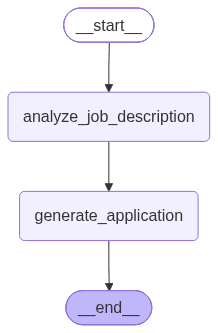

In [2]:
from typing_extensions import TypedDict

#Defining the State Schema
class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str

#Defining a simple workflow
from langgraph.graph import StateGraph, START, END#, Graph

def analyze_job_description(state):
    print("...Analyzing  a provided job description...")
    return {"is_suitable": len(state["job_description"]) > 100}

def generate_application(state):
    print("...generating application..")
    return {"application": "some_fake_application"}

builder = StateGraph(JobApplicationState)
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)

builder.add_edge(START, "analyze_job_description")
builder.add_edge("analyze_job_description", "generate_application")
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
from langchain_core.runnables import Runnable
isinstance(graph, Runnable)

True

In [6]:
res = graph.invoke({"job_description":"fake_id"})

...Analyzing  a provided job description...
...generating application..


In [7]:
print(res)

{'job_description': 'fake_id', 'is_suitable': False, 'application': 'some_fake_application'}


### LangGraph with *supersteps*

In [10]:
from typing import Literal

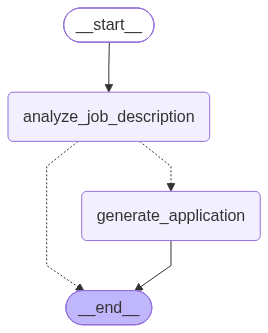

In [12]:
builder = StateGraph(JobApplicationState)
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)

def is_suitable_condition(state: JobApplicationState) -> Literal["generate_application", END]:
    if state.get("is_suitable"):
        return "generate_application"
    return END

builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges("analyze_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### using *add* method as reducer

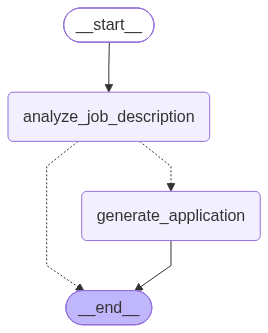

In [13]:
from typing import Annotated, Optional
from operator import add

class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str
    actions: Annotated[list[str], add]

def analyze_job_description(state):
    print("...Analyzing a provided job description ...")
    result = {
        "is_suitable": len(state["job_description"]) < 100,
        "actions": ["action1"]}
    return result

def generate_application(state):
    print("...generating application...")
    return {"application": "some_fake_application", "actions": ["action2"]}



builder = StateGraph(JobApplicationState)
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)
builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges("analyze_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
async for chunk in graph.astream(
    {"job_description": "fake_id"},
    stream_mode="values"):
    print(chunk)
    print("\n\n")

{'job_description': 'fake_id', 'actions': []}



...Analyzing a provided job description ...
{'job_description': 'fake_id', 'is_suitable': True, 'actions': ['action1']}



...generating application...
{'job_description': 'fake_id', 'is_suitable': True, 'application': 'some_fake_application', 'actions': ['action1', 'action2']}





### Making graphs configurable with *RunnableConfig*

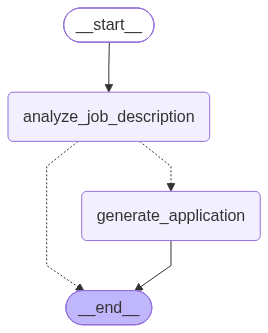

In [15]:
from langchain_core.runnables.config import RunnableConfig

def generate_application(state: JobApplicationState, config: RunnableConfig):
    model_provider = config["configurable"].get("model_provider", "Google")
    model_name = config["configurable"].get("model_name", "gemini-2.0-flash-lite")
    print(f"....generating application with {model_provider} and {model_name}...")
    return {"application": "some_fake_application", "actions":["action2", "action3"]}

builder = StateGraph(JobApplicationState)
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)
builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges("analyze_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
res = graph.invoke({"job_description":"fake_jd"}, config={"configurable": {"model_provider": "OpenAI", "model_name": "gpt-4o"}})
print(res)

...Analyzing a provided job description ...
....generating application with OpenAI and gpt-4o...
{'job_description': 'fake_jd', 'is_suitable': True, 'application': 'some_fake_application', 'actions': ['action1', 'action2', 'action3']}
